In [26]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors as pc
from scipy.stats import spearmanr, ttest_1samp
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm

In [12]:
headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json"
}

def fetch_singstat_table(table_id, search=None, offset=0, limit=20000):
    url = f"https://tablebuilder.singstat.gov.sg/api/table/tabledata/{table_id}"
    params = {"offset": offset, "limit": limit}
    if search:
        params["search"] = search
    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()
    return response.json()

def singstat_rows_to_long_df(data):
    records = []
    for row in data["Data"]["row"]:
        for col in row["columns"]:
            records.append({
                "month": col["key"],
                "metric": row["rowText"],
                "value": col["value"]
            })
    df = pd.DataFrame(records)
    df["month"] = pd.to_datetime(df["month"], format="%Y %b", errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df

def extract_motorcycle_series(table_id, value_name):
    data = fetch_singstat_table(table_id, search="motorcycle")
    rows = data["Data"]["row"]
    matched = [r for r in rows if "motorcycle" in r["rowText"].lower()]
    if not matched:
        raise ValueError(f"No motorcycle row found for {table_id}")
    if len(matched) > 1:
        print(f"Multiple motorcycle rows in {table_id}:")
        for r in matched:
            print(r["seriesNo"], "-", r["rowText"])
    row = matched[0]
    records = [{"month": c["key"], value_name: c["value"]} for c in row["columns"]]
    df = pd.DataFrame(records)
    df["month"] = pd.to_datetime(df["month"], format="%Y %b", errors="coerce")
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
    return df.sort_values("month").reset_index(drop=True)

In [13]:
# COE motorcycle table
motor_coe_data = fetch_singstat_table("M651121", search="motorcycle")
motor_coe_long = singstat_rows_to_long_df(motor_coe_data)
motor_coe_df = motor_coe_long.pivot(index="month", columns="metric", values="value").reset_index()

# Population / dereg / new reg
motor_pop_df = extract_motorcycle_series("M650341", "pop")   # swap to M650271 if needed
motor_dereg_df = extract_motorcycle_series("M650291", "dereg")
motor_newreg_df = extract_motorcycle_series("M650281", "reg")

# Merge
master_df = (
    motor_coe_df
    .merge(motor_pop_df, on="month", how="outer")
    .merge(motor_dereg_df, on="month", how="outer")
    .merge(motor_newreg_df, on="month", how="outer")
    .sort_values("month")
    .reset_index(drop=True)
)

rename_map = {
    "Motorcycles, Quota, 1st Bidding": "quota_1st",
    "Motorcycles, Successful Bids, 1st Bidding": "success_1st",
    "Motorcycles, Bids Received, 1st Bidding": "bids_1st",
    "Motorcycles, Quota Premium, 1st Bidding": "premium_1st",
    "Motorcycles, Quota, 2nd Bidding": "quota_2nd",
    "Motorcycles, Successful Bids, 2nd Bidding": "success_2nd",
    "Motorcycles, Bids Received, 2nd Bidding": "bids_2nd",
    "Motorcycles, Quota Premium, 2nd Bidding": "premium_2nd",
    "Motorcycles, Prevailing Quota Premium, 2nd Bidding": "pqp"
}

master_df = master_df.rename(columns=rename_map)

In [25]:
master_df['quota_total'] = master_df['quota_1st'] + master_df['quota_2nd']
master_df['success_total'] = master_df['success_1st'] + master_df['success_2nd']
master_df['bids_total'] = master_df['bids_1st'] + master_df['bids_2nd']
master_df['premium_avg'] = (master_df['premium_1st'] + master_df['premium_2nd']) /2
master_df = master_df[[
    "month", "quota_1st", "success_1st", "bids_1st", "premium_1st",
    "quota_2nd", "success_2nd", "bids_2nd", "premium_2nd",
    "quota_total", "success_total", "bids_total", "premium_avg",
    "pqp",
    "pop", "dereg", "reg"
]]

master_df = master_df.sort_values("month").reset_index(drop=True)

clean_master_df = master_df.drop(
    columns=master_df.filter(regex="_1st|_2nd").columns
)

print(clean_master_df.tail())

         month  quota_total  success_total  bids_total  premium_avg     pqp  \
425 2025-10-01       1066.0         1056.0      1228.0       9599.5  9252.0   
426 2025-11-01       1076.0         1072.0      1226.0       8664.5  9140.0   
427 2025-12-01       1070.0         1055.0      1259.0       8185.0  8817.0   
428 2026-01-01       1082.0         1050.0      1248.0       8774.5  8542.0   
429 2026-02-01       1098.0         1073.0      1310.0       8139.0  8367.0   

          pop  dereg     reg  
425  150712.0  641.0   938.0  
426  151195.0  547.0  1030.0  
427  151571.0  750.0  1126.0  
428  151758.0  925.0  1112.0  
429       NaN    NaN     NaN  


In [39]:
master = clean_master_df[
    clean_master_df["month"] >= "2002-02-01"
].reset_index(drop=True)

C:\Users\EK\AppData\Local\Temp\ipykernel_31008\439240271.py:13: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



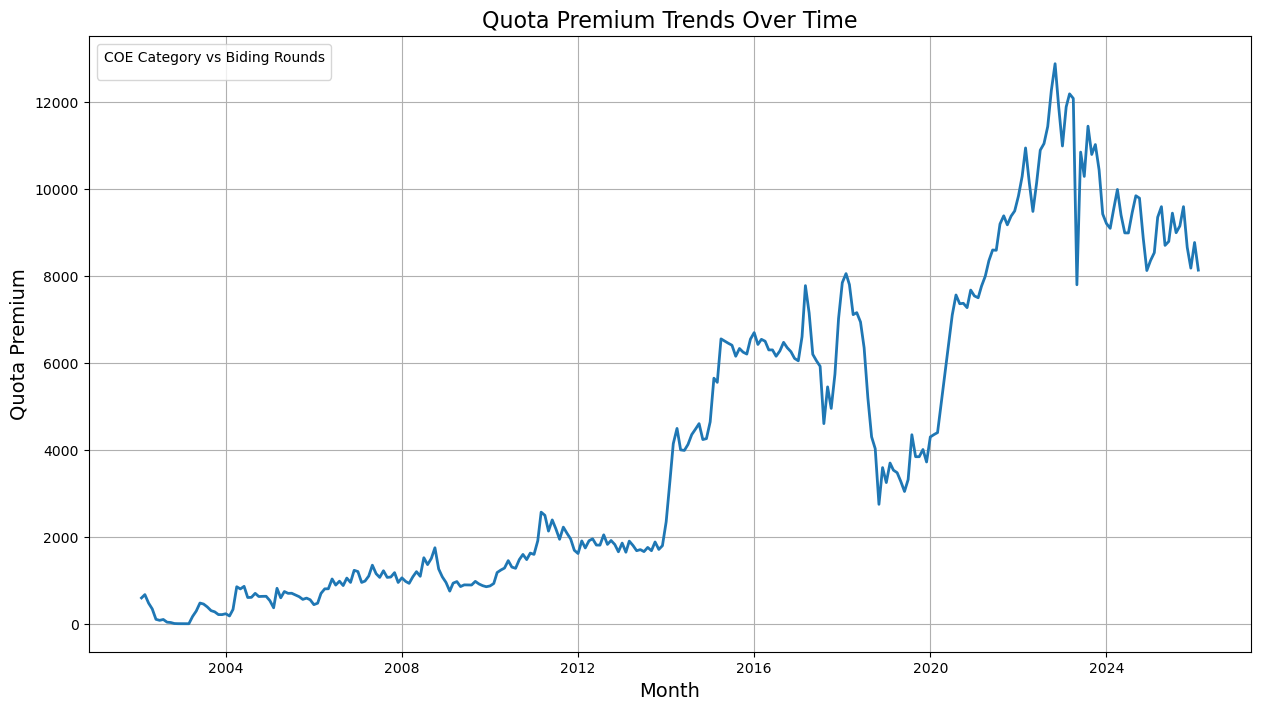

In [40]:
plt.figure(figsize=(15, 8))
sns.lineplot(
    data=master,
    x='month',
    y='premium_avg',
    markers=False,
    dashes=True,
    linewidth=2
)
plt.title("Quota Premium Trends Over Time", fontsize=16)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Quota Premium", fontsize=14)
plt.legend(title="COE Category vs Biding Rounds", fontsize=12)
plt.grid(True)
plt.show()

In [41]:
df = master.copy()

df["netflow"] = df["reg"] - df["dereg"]

df["bid_quota_ratio"] = df["bids_total"] / df["quota_total"]

df["premium_change"] = df["premium_avg"].pct_change()

df["pop_growth"] = df["pop"].pct_change()

df["netflow_roll12"] = df["netflow"].rolling(12).sum()

C:\Users\EK\AppData\Local\Temp\ipykernel_31008\969565967.py:7: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\EK\AppData\Local\Temp\ipykernel_31008\969565967.py:9: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



In [43]:
import plotly.express as px

px.line(
    df,
    x="month",
    y=["quota_total", "bids_total"],
    title="COE Supply vs Demand"
).show()

In [46]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.colors as pc

df = df.set_index("month")

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    row_heights=[1, 1, 1],
    subplot_titles=(
        "Category D Population vs Premium",
        "Category D New Registrations vs Deregistrations",
        "Category D Net Supply Flow vs Quota Premium"
    ),
    specs=[
        [{"secondary_y": True}],
        [{}],
        [{"secondary_y": True}]
    ]
)

# Row 1: Population vs Premium
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['pop'],
        mode='lines',
        name='Population (Cat D)',
        line=dict(color=pc.qualitative.Plotly[0])
    ),
    row=1, col=1, secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['premium_avg'],
        mode='lines',
        name='Quota Premium',
        line=dict(color=pc.qualitative.Plotly[1])
    ),
    row=1, col=1, secondary_y=True
)


# Row 2: New Registrations vs Dereg
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['reg'],
        mode='lines',
        name='New Registrations',
        line=dict(color=pc.qualitative.Plotly[2])
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['dereg'],
        mode='lines',
        name='Deregistrations',
        line=dict(color=pc.qualitative.Plotly[3])
    ),
    row=2, col=1
)


# Row 3: Net Flow vs Premium
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['netflow'],
        mode='lines',
        name='Net Flow (Dereg − New)',
        line=dict(color=pc.qualitative.Plotly[4])
    ),
    row=3, col=1, secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['premium_avg'],
        mode='lines',
        name='Quota Premium',
        line=dict(color=pc.qualitative.Plotly[1]),
        showlegend=False
    ),
    row=3, col=1, secondary_y=True
)


fig.update_layout(
    height=1300,
    width=1000,
    title={
        'text': "Category D COE: Population, Supply Flows & Price Dynamics",
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20}
    },
    template='plotly_dark',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.2,
        xanchor="center",
        x=0.5
    )
)

fig.update_xaxes(title_text="Month-Year")

fig.update_yaxes(title_text="Vehicle Population", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="Quota Premium (SGD)", row=1, col=1, secondary_y=True)

fig.update_yaxes(title_text="Number of Vehicles", row=2, col=1)

fig.update_yaxes(title_text="Net Flow", row=3, col=1, secondary_y=False)
fig.update_yaxes(title_text="Quota Premium (SGD)", row=3, col=1, secondary_y=True)

fig.show()
